## 1)Importacion de Librerias##

In [6]:
import sys
print(sys.executable)

C:\Users\alfon\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2)Configuración de visualización##

In [8]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3)cargas de datasets

In [9]:
df_bank = pd.read_csv("C:/Users/alfon/Desktop/Master/Python/Python for data/Proyecto/Datos en bruto/bank-additional.csv")

df_customers = pd.read_excel("C:/Users/alfon/Desktop/Master/Python/Python for data/Proyecto/Datos en bruto/customer-details.xlsx", sheet_name=None)

4) # Comprobacion de carga

In [10]:
print("BANK CSV cargado correctamente:")
print(df_bank.shape)
print(df_bank.head())

print("\nCUSTOMERS EXCEL cargado correctamente:")
for sheet_name, df_sheet in df_customers.items():
    print(f"Hoja: {sheet_name}, tamaño: {df_sheet.shape}")
    print(df_sheet.head())

BANK CSV cargado correctamente:
(43000, 24)
   Unnamed: 0   age        job  marital    education  default  housing  loan  \
0           0   NaN  housemaid  MARRIED     basic.4y      0.0      0.0   0.0   
1           1  57.0   services  MARRIED  high.school      NaN      0.0   0.0   
2           2  37.0   services  MARRIED  high.school      0.0      1.0   0.0   
3           3  40.0     admin.  MARRIED     basic.6y      0.0      0.0   0.0   
4           4  56.0   services  MARRIED  high.school      0.0      0.0   1.0   

     contact  duration  ...  emp.var.rate  cons.price.idx  cons.conf.idx  \
0  telephone       261  ...           1.1          93,994          -36,4   
1  telephone       149  ...           1.1          93,994          -36,4   
2  telephone       226  ...           1.1          93,994          -36,4   
3  telephone       151  ...           1.1          93,994          -36,4   
4  telephone       307  ...           1.1          93,994          -36,4   

  euribor3m  nr.em

#5) Limpieza de datos bank-additional

In [13]:
print("\n--- LIMPIEZA DF_BANK ---")

# Ver nulos
print("\nValores nulos por columna:")
print(df_bank.isnull().sum())

# Eliminar duplicados
print("\nDuplicados eliminados:", df_bank.duplicated().sum())
df_bank = df_bank.drop_duplicates()

# Convertir columnas numéricas correctamente
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous']
for col in num_cols:
    if col in df_bank.columns:
        df_bank[col] = pd.to_numeric(df_bank[col], errors='coerce')

# Limpiar columna 'date' (está en español)
df_bank['date'] = (
    df_bank['date']
    .str.replace("-", " ", regex=False)
    .str.replace("enero", "January")
    .str.replace("febrero", "February")
    .str.replace("marzo", "March")
    .str.replace("abril", "April")
    .str.replace("mayo", "May")
    .str.replace("junio", "June")
    .str.replace("julio", "July")
    .str.replace("agosto", "August")
    .str.replace("septiembre", "September")
    .str.replace("octubre", "October")
    .str.replace("noviembre", "November")
    .str.replace("diciembre", "December")
)

df_bank['date'] = pd.to_datetime(df_bank['date'], errors='coerce')

# Renombrar columna id_
df_bank = df_bank.rename(columns={'id_': 'ID'})

print("\nTipos de datos después de limpieza:")
print(df_bank.dtypes)



--- LIMPIEZA DF_BANK ---

Valores nulos por columna:
Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

Duplicados eliminados: 0

Tipos de datos después de limpieza:
Unnamed: 0                 int64
age                      float64
job                          str
marital                      str
education                    str
default                  float64
housing                  float64
loan                     float64
contact                      str
duration             

# 6)Limpieza datos customer-detail

In [14]:
print("\n--- LIMPIEZA DF_CUSTOMERS ---")

clean_sheets = {}

for sheet_name, df_sheet in df_customers.items():

    print(f"\nHoja: {sheet_name}")

    # Eliminar duplicados
    print("Duplicados eliminados:", df_sheet.duplicated().sum())
    df_sheet = df_sheet.drop_duplicates()

    # Convertir fecha
    df_sheet['Dt_Customer'] = pd.to_datetime(df_sheet['Dt_Customer'], errors='coerce')

    # Convertir numéricos
    num_cols = ['Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth']
    for col in num_cols:
        df_sheet[col] = pd.to_numeric(df_sheet[col], errors='coerce')

    clean_sheets[sheet_name] = df_sheet

df_customers = clean_sheets


--- LIMPIEZA DF_CUSTOMERS ---

Hoja: 2012
Duplicados eliminados: 0

Hoja: 2013
Duplicados eliminados: 0

Hoja: 2014
Duplicados eliminados: 0


# 7)Deteccion outliers

In [15]:
def detectar_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
    return outliers

print("\nOutliers en edad:")
print(detectar_outliers(df_bank, 'age').head())


Outliers en edad:
       Unnamed: 0   age      job   marital          education  default  \
27569       27713  70.0  retired  DIVORCED           basic.4y      0.0   
27613       27757  76.0  retired   MARRIED  university.degree      0.0   
27636       27780  73.0  retired   MARRIED  university.degree      0.0   
27656       27800  88.0  retired  DIVORCED           basic.4y      0.0   
27658       27802  88.0  retired  DIVORCED           basic.4y      0.0   

       housing  loan   contact  duration  ...  emp.var.rate  cons.price.idx  \
27569      1.0   0.0  cellular       187  ...          -1.8          92,843   
27613      0.0   1.0  cellular       167  ...          -1.8          92,843   
27636      1.0   0.0  cellular       179  ...          -1.8          92,843   
27656      1.0   0.0  cellular        48  ...          -1.8          92,843   
27658      0.0   0.0  cellular       266  ...          -1.8          92,843   

       cons.conf.idx euribor3m  nr.employed    y       date l

# 8) Unimos datasets por la columna ID que es la que tienen en comun

In [17]:
print("\n--- UNIÓN DE DATASETS ---")

merged_sheets = []

for sheet_name, df_sheet in df_customers.items():
    print(f"Uniendo hoja {sheet_name}...")

    df_merged = pd.merge(df_bank, df_sheet, on="ID", how="inner")

    print(f"Hoja {sheet_name} unida. Tamaño: {df_merged.shape}")

    merged_sheets.append(df_merged)

df_final = pd.concat(merged_sheets, ignore_index=True)

print("\n--- DATASET FINAL ---")
print("Tamaño total:", df_final.shape)
print(df_final.head())


--- UNIÓN DE DATASETS ---
Uniendo hoja 2012...
Hoja 2012 unida. Tamaño: (20018, 30)
Uniendo hoja 2013...
Hoja 2013 unida. Tamaño: (8918, 30)
Uniendo hoja 2014...
Hoja 2014 unida. Tamaño: (14064, 30)

--- DATASET FINAL ---
Tamaño total: (43000, 30)
   Unnamed: 0_x   age        job  marital    education  default  housing  \
0             0   NaN  housemaid  MARRIED     basic.4y      0.0      0.0   
1             1  57.0   services  MARRIED  high.school      NaN      0.0   
2             2  37.0   services  MARRIED  high.school      0.0      1.0   
3             3  40.0     admin.  MARRIED     basic.6y      0.0      0.0   
4             4  56.0   services  MARRIED  high.school      0.0      0.0   

   loan    contact  duration  ...       date  latitude  longitude  \
0   0.0  telephone       261  ... 2019-08-02    41.495    -71.233   
1   0.0  telephone       149  ... 2016-09-14    34.601    -83.923   
2   0.0  telephone       226  ... 2019-02-15    34.939    -94.847   
3   0.0  telephone

# 9)Distribuciones básicas de variables importantes

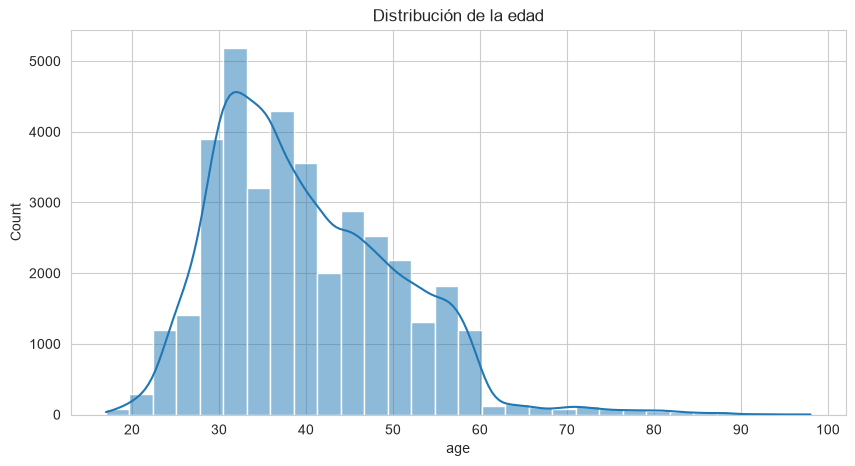

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(df_final['age'], kde=True, bins=30)
plt.title("Distribución de la edad")
plt.show()

# 10) Estadisticas principales

In [19]:
print("\nEstadísticas descriptivas - Variables numéricas:")
print(df_final.describe())


Estadísticas descriptivas - Variables numéricas:
       Unnamed: 0_x           age       default       housing          loan  \
count  43000.000000  37880.000000  34019.000000  41974.000000  41974.000000   
mean   20651.099047     39.977112      0.000088      0.535998      0.155620   
min        0.000000     17.000000      0.000000      0.000000      0.000000   
25%    10381.750000     32.000000      0.000000      0.000000      0.000000   
50%    20642.500000     38.000000      0.000000      1.000000      0.000000   
75%    30930.250000     47.000000      0.000000      1.000000      0.000000   
max    41187.000000     98.000000      1.000000      1.000000      1.000000   
std    11868.770913     10.437957      0.009390      0.498708      0.362499   

           duration      campaign         pdays      previous  emp.var.rate  \
count  43000.000000  43000.000000  43000.000000  43000.000000  43000.000000   
mean     257.739279      2.567233    962.330953      0.174023      0.077128   
m

In [20]:
print("\nFrecuencias - Variables categóricas:")
for col in ['job', 'marital', 'education', 'y']:
    if col in df_final.columns:
        print(f"\n{col.upper()}:")
        print(df_final[col].value_counts())


Frecuencias - Variables categóricas:

JOB:
job
admin.           10873
blue-collar       9654
technician        7026
services          4162
management        3050
retired           1790
entrepreneur      1522
self-employed     1489
housemaid         1123
unemployed        1063
student            903
Name: count, dtype: int64

MARITAL:
marital
MARRIED     25999
SINGLE      12105
DIVORCED     4811
Name: count, dtype: int64

EDUCATION:
education
university.degree      12722
high.school             9925
basic.9y                6309
professional.course     5477
basic.4y                4356
basic.6y                2386
illiterate                18
Name: count, dtype: int64

Y:
y
no     38156
yes     4844
Name: count, dtype: int64


# 11) Analisis de la Variable Y (quien contrata un deposito)

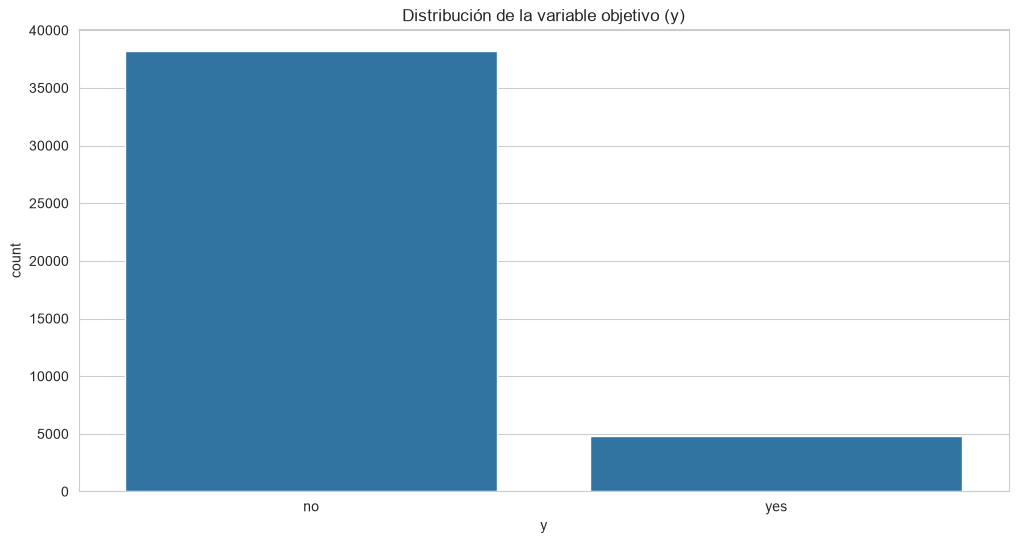

In [22]:
df_final['y'].value_counts()
sns.countplot(data=df_final, x='y')
plt.title("Distribución de la variable objetivo (y)")
plt.show()

# 12) Distribuciones basicas

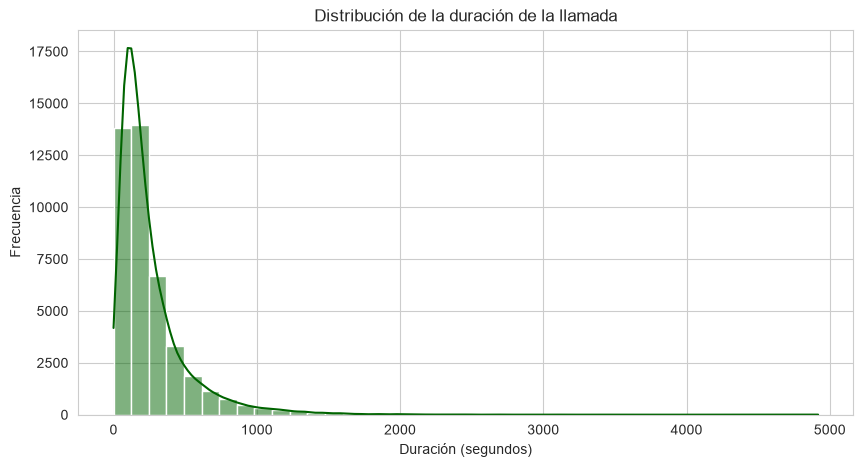

In [26]:
## Duracion de la llamada

plt.figure(figsize=(10,5))
sns.histplot(df_final['duration'], kde=True, bins=40, color='darkgreen')
plt.title("Distribución de la duración de la llamada")
plt.xlabel("Duración (segundos)")
plt.ylabel("Frecuencia")
plt.show()

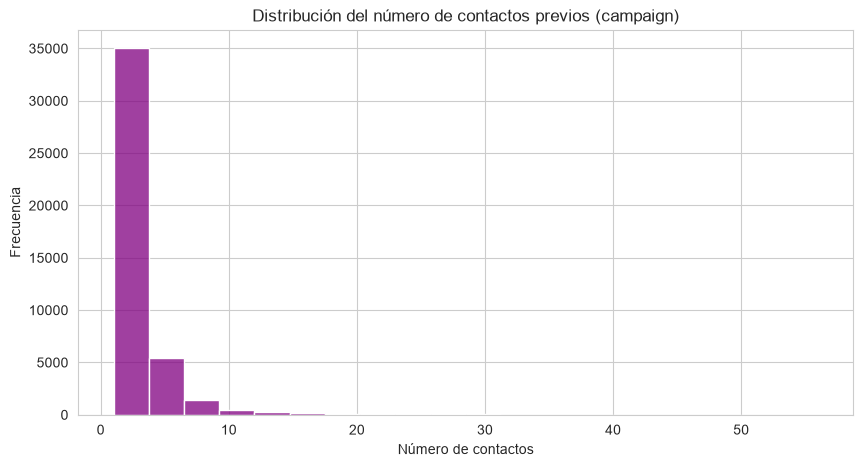

In [27]:
##Distribución del número de contactos previos (campaign)

plt.figure(figsize=(10,5))
sns.histplot(df_final['campaign'], kde=False, bins=20, color='purple')
plt.title("Distribución del número de contactos previos (campaign)")
plt.xlabel("Número de contactos")
plt.ylabel("Frecuencia")
plt.show()

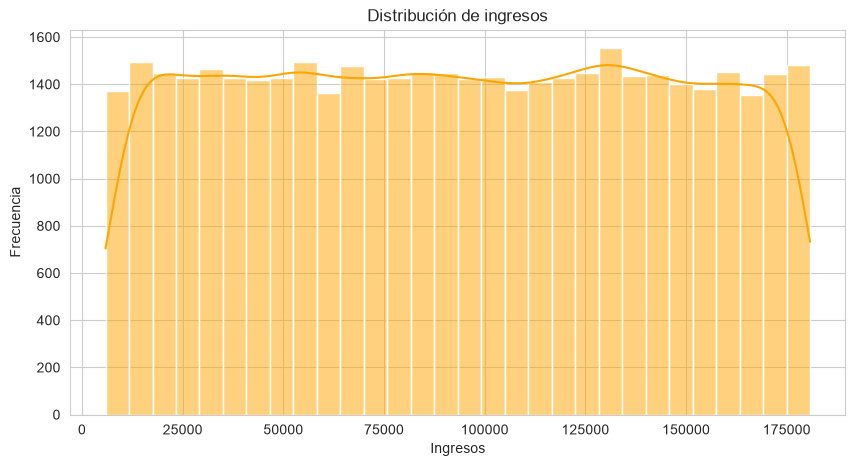

In [28]:
# Distribución de ingresos (Income)
plt.figure(figsize=(10,5))
sns.histplot(df_final['Income'], kde=True, bins=30, color='orange')
plt.title("Distribución de ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.show()

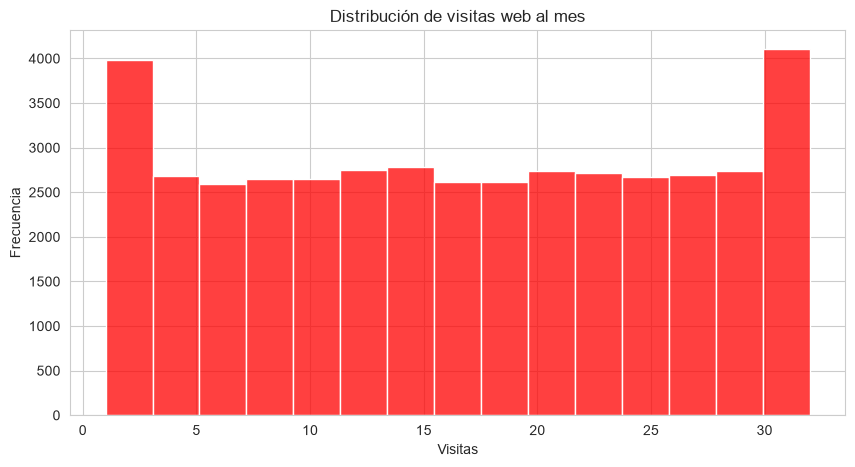

In [29]:
# Distribución de visitas web al mes
plt.figure(figsize=(10,5))
sns.histplot(df_final['NumWebVisitsMonth'], kde=False, bins=15, color='red')
plt.title("Distribución de visitas web al mes")
plt.xlabel("Visitas")
plt.ylabel("Frecuencia")
plt.show()

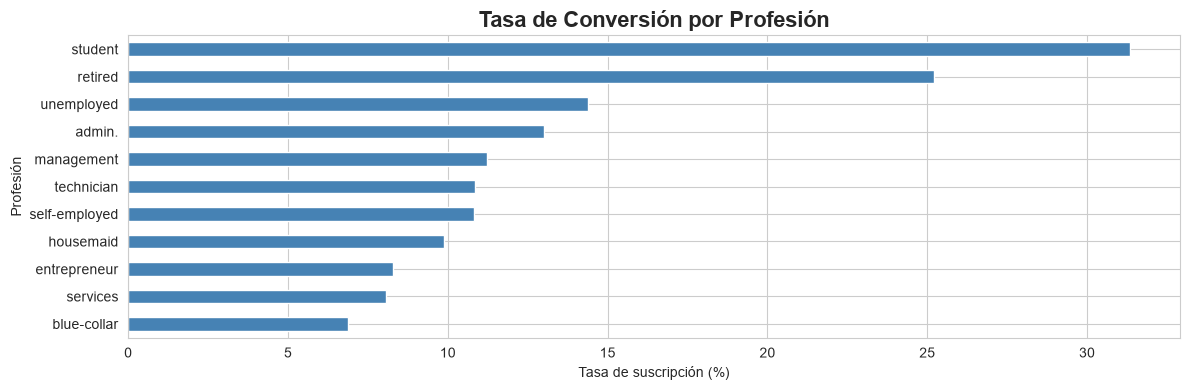

In [55]:
plt.figure(figsize=(12, 4))
tabla_job_sorted = tabla_job.sort_values(by='tasa_yes', ascending=True)
tabla_job_sorted['tasa_yes'].plot(kind='barh', color='steelblue')
plt.title('Tasa de Conversión por Profesión', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de suscripción (%)')
plt.ylabel('Profesión')
plt.tight_layout()
plt.show()

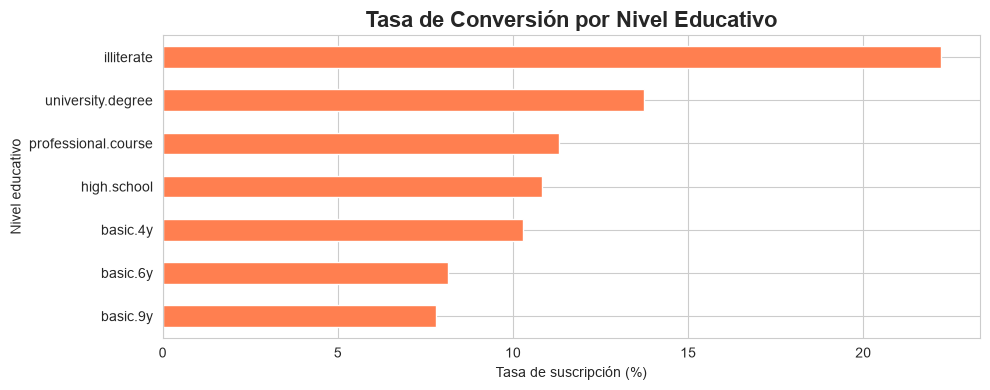

In [56]:
plt.figure(figsize=(10, 4))
tabla_education_sorted = tabla_education.sort_values(by='tasa_yes', ascending=True)
tabla_education_sorted['tasa_yes'].plot(kind='barh', color='coral')
plt.title('Tasa de Conversión por Nivel Educativo', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de suscripción (%)')
plt.ylabel('Nivel educativo')
plt.tight_layout()
plt.show()

# 13) ANÁLISIS DE CORRELACIONES

In [30]:
df_num = df_final.select_dtypes(include=['int64', 'float64'])
print("Columnas numéricas:", df_num.columns.tolist())

Columnas numéricas: ['Unnamed: 0_x', 'age', 'default', 'housing', 'loan', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'latitude', 'longitude', 'Unnamed: 0_y', 'Income', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth']


In [31]:
corr_matrix = df_num.corr()
corr_matrix

,Unnamed: 0_x,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude,Unnamed: 0_y,Income,Kidhome,Teenhome,NumWebVisitsMonth
Unnamed: 0_x,1.000000,0.006825,0.000512,0.085736,0.005938,0.007864,-0.095468,-0.284532,0.427965,-0.835517,0.004707,0.000755,-0.010123,0.006073,0.001176,-0.003441,0.007606
age,0.006825,1.000000,0.006932,-0.000502,-0.001017,-0.000073,0.005374,-0.035639,0.024399,-0.002948,0.000796,0.006360,0.010376,0.001463,0.000987,-0.001046,-0.003767
default,0.000512,0.006932,1.000000,-0.003952,-0.004094,-0.005620,-0.004109,0.002033,0.002327,0.005725,0.000715,-0.000270,-0.009821,0.002141,0.003790,0.000016,0.003817
housing,0.085736,-0.000502,-0.003952,1.000000,0.045448,-0.008682,-0.011045,-0.009825,0.019514,-0.060096,-0.001363,-0.003269,-0.010895,0.000470,0.004239,0.003647,-0.004113
loan,0.005938,-0.001017,-0.004094,0.045448,1.000000,-0.000924,0.004186,-0.000232,-0.000775,0.001225,-0.000126,0.000885,0.005776,0.003440,0.000005,0.003242,-0.003354
duration,0.007864,-0.000073,-0.005620,-0.008682,-0.000924,1.000000,-0.071956,-0.047632,0.021285,-0.027158,-0.004131,0.003563,0.015646,-0.002761,-0.000759,-0.005937,0.000750
campaign,-0.095468,0.005374,-0.004109,-0.011045,0.004186,-0.071956,1.000000,0.053292,-0.079603,0.152084,-0.009589,-0.000568,0.087665,-0.003736,-0.006733,0.000802,0.004470
pdays,-0.284532,-0.035639,0.002033,-0.009825,-0.000232,-0.047632,0.053292,1.000000,-0.589317,0.270689,0.001238,0.002152,-0.050801,0.004092,0.000531,0.004627,-0.001522
previous,0.427965,0.024399,0.002327,0.019514,-0.000775,0.021285,-0.079603,-0.589317,1.000000,-0.419110,0.011632,-0.010392,-0.011995,-0.003207,-0.000851,-0.003012,-0.001967
emp.var.rate,-0.835517,-0.002948,0.005725,-0.060096,0.001225,-0.027158,0.152084,0.270689,-0.419110,1.000000,-0.008496,0.000301,0.219092,-0.008640,-0.004026,0.001431,-0.006914


In [ ]:
## suscripción por profesión

tabla_job = pd.crosstab(df_final['job'], df_final['y'])
tabla_job['tasa_yes'] = tabla_job['yes'] / tabla_job.sum(axis=1) * 100

print("\nTasa de suscripción por profesión:")
print(tabla_job.sort_values(by='tasa_yes', ascending=False))


Tasa de suscripción por profesión:
y                no   yes   tasa_yes
job                                 
student         620   283  31.339978
retired        1339   451  25.195531
unemployed      910   153  14.393227
admin.         9458  1415  13.013888
management     2708   342  11.213115
technician     6264   762  10.845431
self-employed  1328   161  10.812626
housemaid      1012   111   9.884239
entrepreneur   1396   126   8.278581
services       3826   336   8.073042
blue-collar    8989   665   6.888336


In [ ]:
## suscripción por nivel educativo

tabla_education = pd.crosstab(df_final['education'], df_final['y'])
tabla_education['tasa_yes'] = tabla_education['yes'] / tabla_education.sum(axis=1) * 100

print("\nTasa de suscripción por nivel educativo:")
print(tabla_education.sort_values(by='tasa_yes', ascending=False))


Tasa de suscripción por nivel educativo:
y                       no   yes   tasa_yes
education                                  
illiterate              14     4  22.222222
university.degree    10974  1748  13.739978
professional.course   4857   620  11.320066
high.school           8849  1076  10.841310
basic.4y              3908   448  10.284665
basic.6y              2192   194   8.130763
basic.9y              5816   493   7.814234


In [ ]:
## Suscripcion por estado civil

tabla_marital = pd.crosstab(df_final['marital'], df_final['y'])
tabla_marital['tasa_yes'] = tabla_marital['yes'] / tabla_marital.sum(axis=1) * 100

print("\nTasa de suscripción por estado civil:")
print(tabla_marital.sort_values(by='tasa_yes', ascending=False))


Tasa de suscripción por estado civil:
y            no   yes   tasa_yes
marital                         
SINGLE    10419  1686  13.928129
MARRIED   23344  2655  10.211931
DIVORCED   4321   490  10.184993


In [ ]:
## Suscripcion hipoteca

tabla_housing = pd.crosstab(df_final['housing'], df_final['y'])
tabla_housing['tasa_yes'] = tabla_housing['yes'] / tabla_housing.sum(axis=1) * 100

print("\nTasa de suscripción según hipoteca:")
print(tabla_housing.sort_values(by='tasa_yes', ascending=False))


Tasa de suscripción según hipoteca:
y           no   yes   tasa_yes
housing                        
1.0      19882  2616  11.627700
0.0      17362  2114  10.854385


In [ ]:
##Suscripcion prestamos

tabla_loan = pd.crosstab(df_final['loan'], df_final['y'])
tabla_loan['tasa_yes'] = tabla_loan['yes'] / tabla_loan.sum(axis=1) * 100

print("\nTasa de suscripción según préstamo personal:")
print(tabla_loan.sort_values(by='tasa_yes', ascending=False))


Tasa de suscripción según préstamo personal:
y        no   yes   tasa_yes
loan                        
0.0   31425  4017  11.334010
1.0    5819   713  10.915493


In [ ]:
##Suscripcioniimpagos

tabla_default = pd.crosstab(df_final['default'], df_final['y'])
tabla_default['tasa_yes'] = tabla_default['yes'] / tabla_default.sum(axis=1) * 100
tabla_default['total'] = tabla_default[['no', 'yes']].sum(axis=1)

print("\nTasa de suscripción según impagos:")
print(tabla_default.sort_values('total', ascending=False))


Tasa de suscripción según impagos:
y           no   yes   tasa_yes  total
default                               
0.0      29640  4376  12.864534  34016
1.0          3     0   0.000000      3


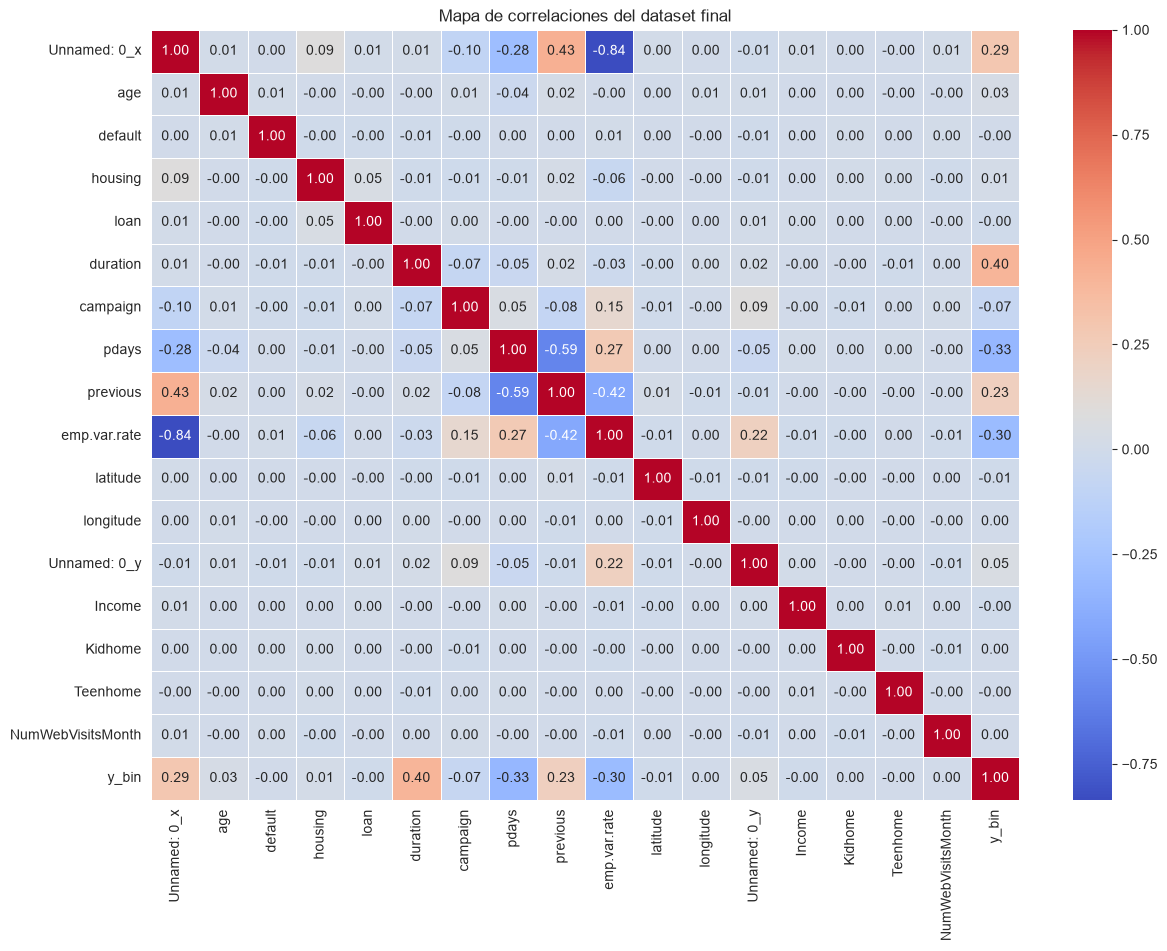

In [35]:
df_num = df_final.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_num.corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Mapa de correlaciones del dataset final")
plt.show()

C:\Users\alfon\AppData\Local\Temp\ipykernel_12436\1643982618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')


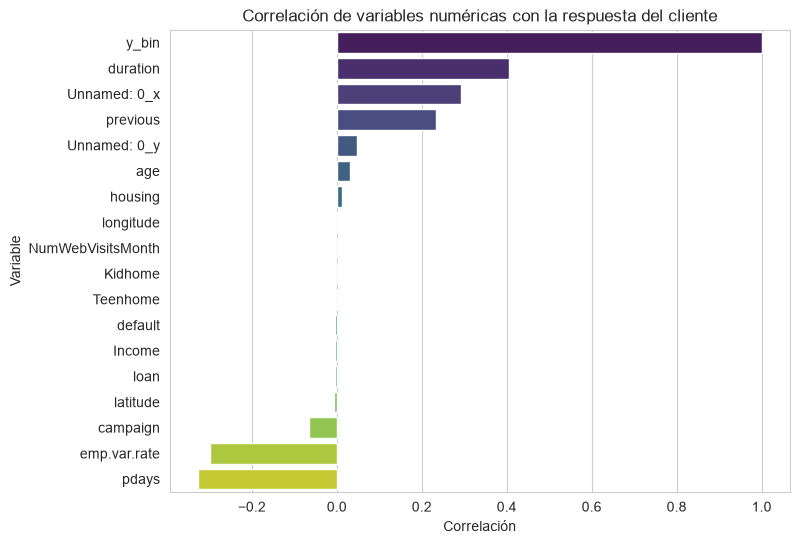

In [36]:
if 'y' in df_final.columns:
    df_final['y_bin'] = df_final['y'].map({'yes':1, 'no':0})
    corr_target = df_num.corr()['y_bin'].sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
    plt.title("Correlación de variables numéricas con la respuesta del cliente")
    plt.xlabel("Correlación")
    plt.ylabel("Variable")
    plt.show()

# 14)Boxplots para variables numéricas

C:\Users\alfon\AppData\Local\Temp\ipykernel_12436\2566948937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='y', y='age', palette='Set2')


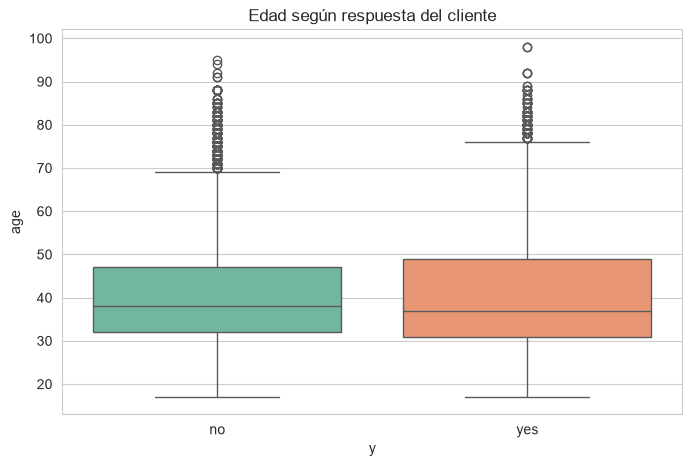

In [ ]:
## edad /respuesta

plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x='y', y='age', palette='Set2')
plt.title("Edad según respuesta del cliente")
plt.show()

C:\Users\alfon\AppData\Local\Temp\ipykernel_12436\443864395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='y', y='duration', palette='Set2')


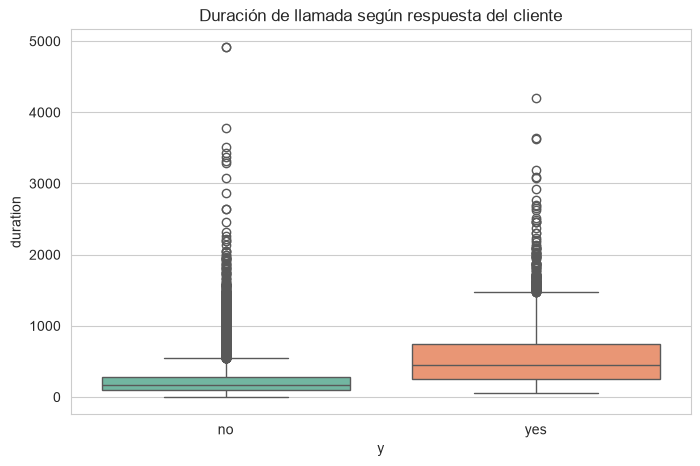

In [40]:
## Duración llamada /respusta

plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x='y', y='duration', palette='Set2')
plt.title("Duración de llamada según respuesta del cliente")
plt.show()

C:\Users\alfon\AppData\Local\Temp\ipykernel_12436\837216237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='y', y='Income', palette='Set2')


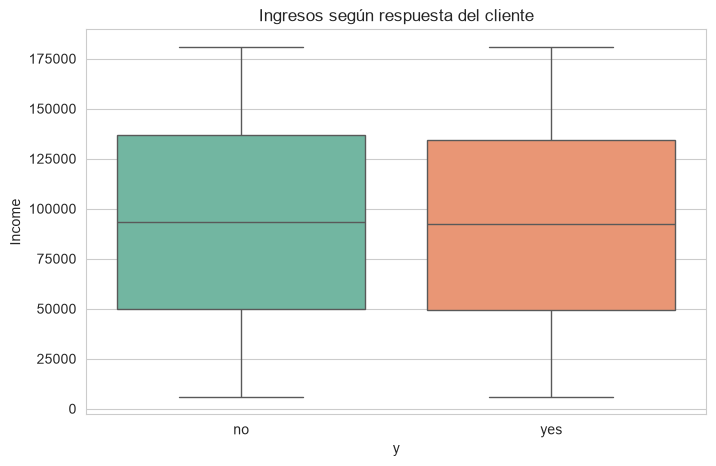

In [41]:
## Ingresos / respuesta

plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x='y', y='Income', palette='Set2')
plt.title("Ingresos según respuesta del cliente")
plt.show()

C:\Users\alfon\AppData\Local\Temp\ipykernel_12436\2803524526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='y', y='age', palette='Set3')


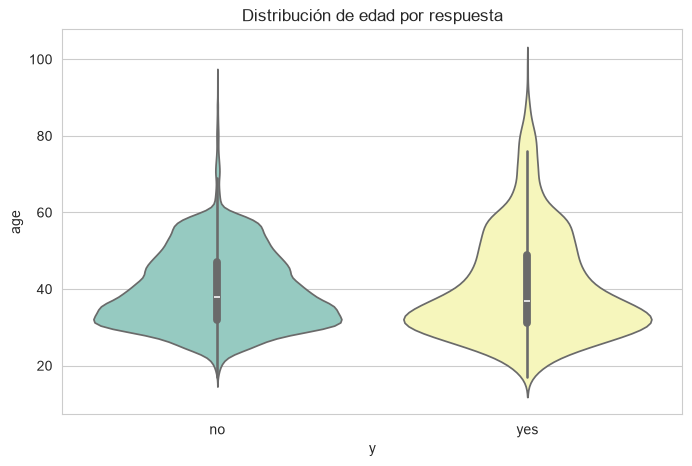

In [42]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df_final, x='y', y='age', palette='Set3')
plt.title("Distribución de edad por respuesta")
plt.show()

C:\Users\alfon\AppData\Local\Temp\ipykernel_12436\3623932273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='y', y='duration', palette='Set3')


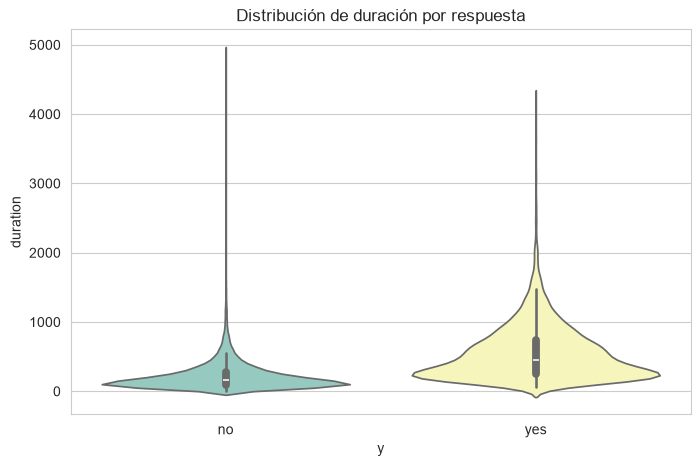

In [43]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df_final, x='y', y='duration', palette='Set3')
plt.title("Distribución de duración por respuesta")
plt.show()

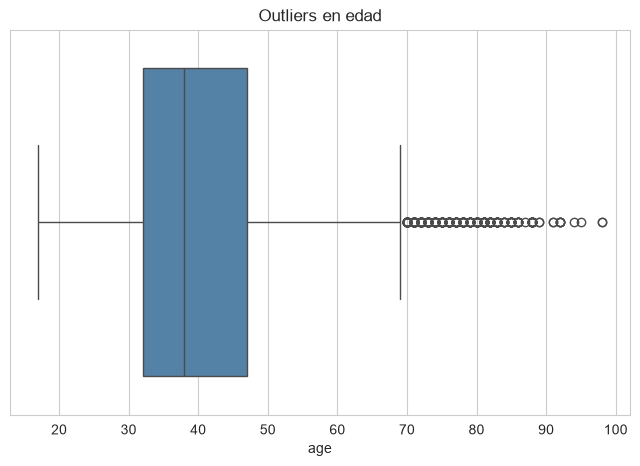

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['age'], color='steelblue')
plt.title("Outliers en edad")
plt.show()

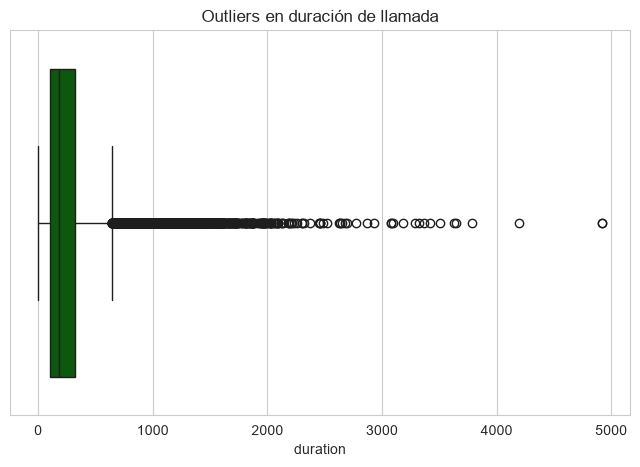

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['duration'], color='darkgreen')
plt.title("Outliers en duración de llamada")
plt.show()

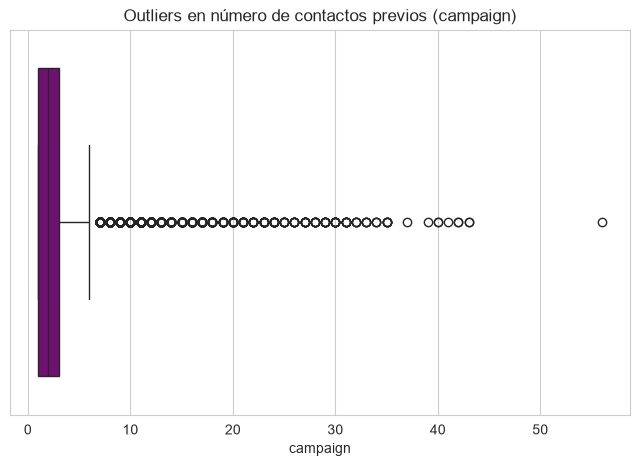

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['campaign'], color='purple')
plt.title("Outliers en número de contactos previos (campaign)")
plt.show()

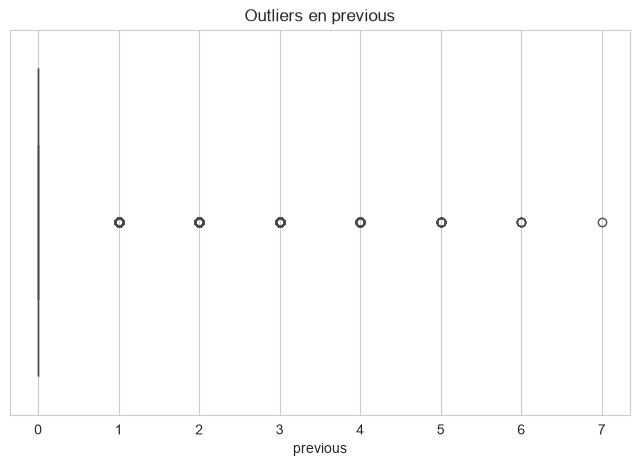

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['previous'], color='red')
plt.title("Outliers en previous")
plt.show()

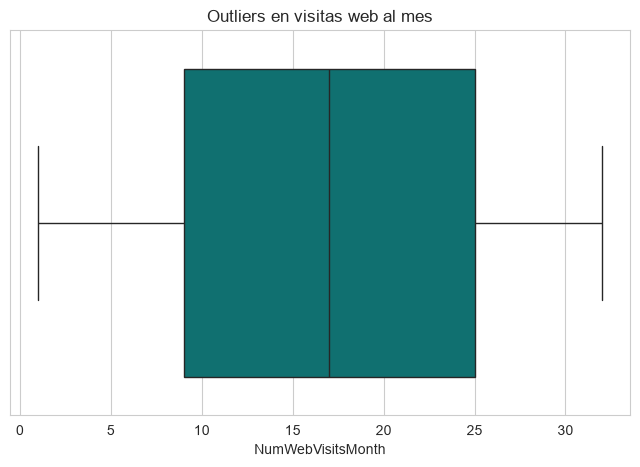

In [62]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_final['NumWebVisitsMonth'], color='teal')
plt.title("Outliers en visitas web al mes")
plt.show()

# 15) Segmentaciones

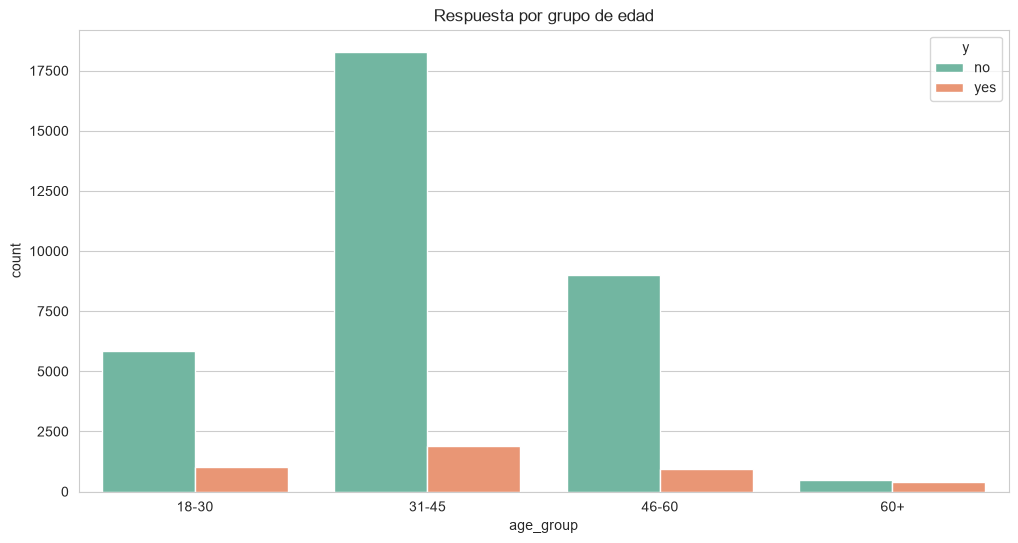

In [63]:
df_final['age_group'] = pd.cut(
    df_final['age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)

sns.countplot(data=df_final, x='age_group', hue='y', palette='Set2')
plt.title("Respuesta por grupo de edad")
plt.show()

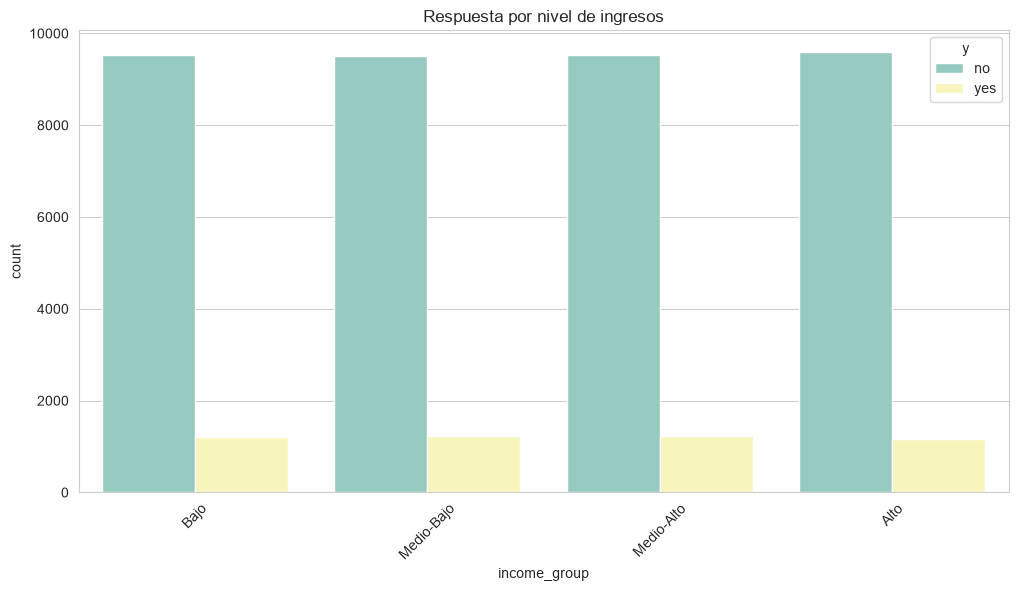

In [64]:
df_final['income_group'] = pd.qcut(
    df_final['Income'],
    q=4,
    labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto']
)

sns.countplot(data=df_final, x='income_group', hue='y', palette='Set3')
plt.title("Respuesta por nivel de ingresos")
plt.xticks(rotation=45)
plt.show()

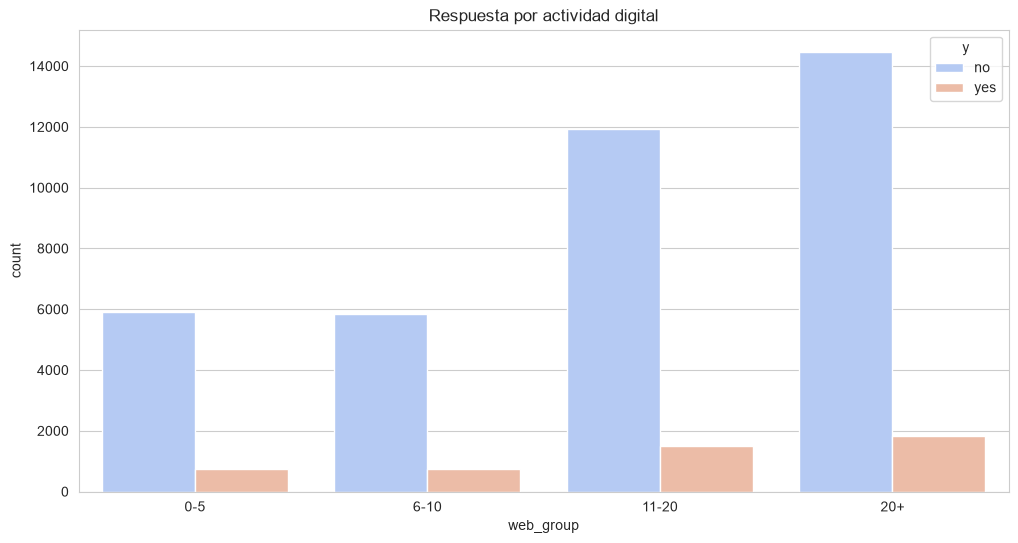

In [65]:
df_final['web_group'] = pd.cut(
    df_final['NumWebVisitsMonth'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5', '6-10', '11-20', '20+']
)

sns.countplot(data=df_final, x='web_group', hue='y', palette='coolwarm')
plt.title("Respuesta por actividad digital")
plt.show()

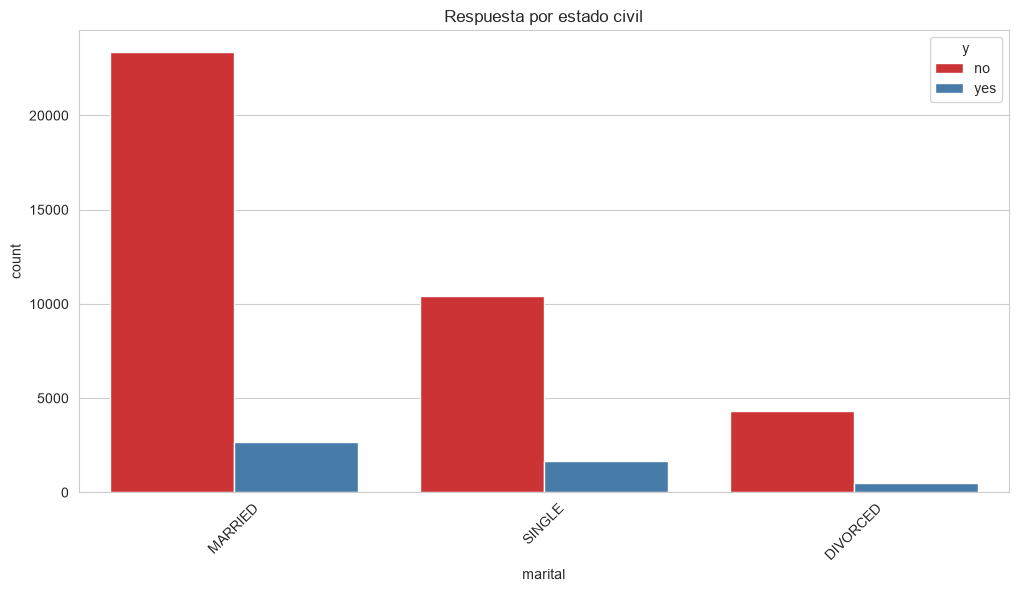

In [66]:
sns.countplot(data=df_final, x='marital', hue='y', palette='Set1')
plt.title("Respuesta por estado civil")
plt.xticks(rotation=45)
plt.show()

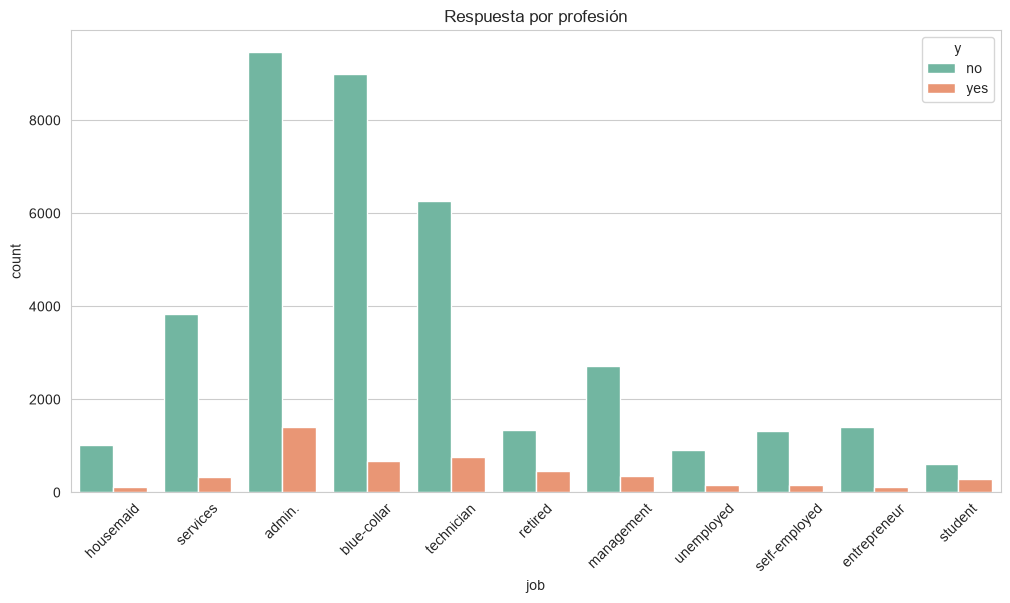

In [67]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_final, x='job', hue='y', palette='Set2')
plt.title("Respuesta por profesión")
plt.xticks(rotation=45)
plt.show()

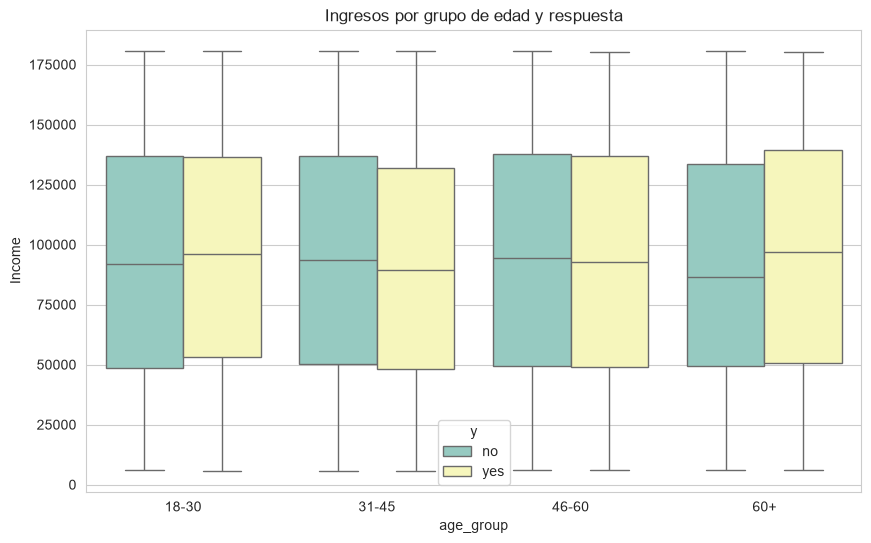

In [68]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_final, x='age_group', y='Income', hue='y', palette='Set3')
plt.title("Ingresos por grupo de edad y respuesta")
plt.show()

Conclusiones de negocio del análisis de la campaña bancaria

1️⃣ Perfil del cliente con mayor probabilidad de aceptar la campaña (y = yes)
Del análisis de segmentación, correlaciones y boxplots se observa que los clientes que aceptan la campaña suelen tener:

Llamadas más largas: la variable duration es la más discriminante.
Cuanto más tiempo permanece el cliente en la llamada, mayor probabilidad de conversión.

Edad media-alta: los grupos de edad 46–60 y 60+ muestran mayor tasa de respuesta positiva.

Profesiones específicas: perfiles como retired, student y admin. tienden a responder mejor.

Menor número de contactos previos (campaign): los clientes que reciben demasiadas llamadas suelen rechazar la oferta.

Clientes con ingresos medios-altos muestran una mayor predisposición a aceptar.

2️⃣ Variables que más influyen en la respuesta
             Variables numéricas clave
duration → correlación más alta con la respuesta.

pdays → valores extremos (999) indican clientes no contactados previamente; estos suelen tener mejor respuesta.

campaign → correlación negativa: demasiados contactos reducen la probabilidad de conversión.

previous → clientes con contactos previos exitosos tienen mayor probabilidad de aceptar.

             Variables categóricas relevantes
job → algunas profesiones responden significativamente mejor.

marital → los clientes casados muestran patrones distintos a solteros/divorciados.

education → niveles educativos más altos tienden a correlacionar con mayor aceptación.

Insights operativos para mejorar la campaña
✔ Optimizar duración de la llamada
Las llamadas más largas convierten más.
Esto sugiere que la calidad del guion y la interacción del agente es clave.

✔ Evitar sobrecontactar
Los clientes con muchos contactos previos (campaign alto) tienen menor probabilidad de aceptar.
Recomendación: limitar el número de intentos por cliente.

✔ Priorizar segmentos de mayor respuesta
Clientes de 46+ años

Profesiones: retired, student, admin.

Ingresos medios-altos

Clientes con actividad digital moderada

✔ Aprovechar clientes sin contacto previo
Los clientes con pdays = 999 (no contactados antes) responden mejor.
Recomendación: priorizar nuevos clientes en la campaña.
